# Exploratory Data Analysis: Aave v3 The Graph Extracts for Markov Calibration

This notebook inspects the **raw** Aave v3 payloads from The Graph, flattens nested position histories, values them in USD, applies actuarial purity filters, and reconstructs an empirical **Health Factor (HF)** panel for Markov calibration.

Both valuation windows are processed in parallel:

- **Baseline scenario:** 30-day window ending 15 March 2024 (`data/01_raw/baseline_mar2024/`)
- **Stress scenario:** 30-day window ending 5 August 2024 (`data/01_raw/stress_aug2024/`)

Each Graph payload contains **`users`** (borrower positions, ~49k records) and **`liquidationCalls`**. Nested reserve histories (`aTokenBalanceHistory`, `vTokenBalanceHistory`) are unnested, expanded to a daily calendar, and crossed with Binance close prices. Protocol constants (`STABLECOINS`, `LST_ASSETS`, `PRICE_PROXIES`, `LIQUIDATION_THRESHOLDS`) are imported from `src.utils.config`.

## 1. Imports

In [20]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(os.path.abspath(".."))
from src.utils.config import (
    LST_ASSETS,
    LIQUIDATION_THRESHOLDS,
    PRICE_PROXIES,
    STABLECOINS,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": True,
        "axes.spines.top": False,
    }
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)

print("STABLECOINS:", STABLECOINS)
print("LST_ASSETS:", LST_ASSETS)
print("PRICE_PROXIES:", PRICE_PROXIES)
print("LIQUIDATION_THRESHOLDS keys:", list(LIQUIDATION_THRESHOLDS.keys()))

STABLECOINS: ['USDC', 'USDT', 'DAI', 'FRAX', 'LUSD', 'GHO']
LST_ASSETS: ['wstETH', 'cbETH', 'rETH']
PRICE_PROXIES: {'ETH': 'ETHUSDT', 'WETH': 'ETHUSDT', 'wstETH': 'ETHUSDT', 'cbETH': 'ETHUSDT', 'rETH': 'ETHUSDT', 'WBTC': 'BTCUSDT', 'UNI': 'UNIUSDT', 'LINK': 'LINKUSDT'}
LIQUIDATION_THRESHOLDS keys: ['ETH', 'WETH', 'wstETH', 'cbETH', 'rETH', 'WBTC', 'UNI', 'LINK', 'USDC', 'USDT', 'DAI', 'FRAX', 'LUSD', 'GHO', 'DEFAULT']


## 2. Data loading

Both Graph JSON extracts are resolved relative to this notebook (`notebooks/`). Folders are iterated as `['baseline_mar2024', 'stress_aug2024']`. Each file is large (~250 MB); both payloads are kept in memory under `payloads`.

In [21]:
RAW_DATA_DIR = Path("../data/01_raw")
SCENARIO_DIRS = ["baseline_mar2024", "stress_aug2024"]
SCENARIO_KEY = {
    "baseline_mar2024": "baseline",
    "stress_aug2024": "stress",
}

payloads: dict[str, dict] = {}

for folder_name in SCENARIO_DIRS:
    scenario_key = SCENARIO_KEY[folder_name]
    json_path = RAW_DATA_DIR / folder_name / "thegraph_hf_30d.json"
    print(f"[{scenario_key}] {json_path.resolve()}")
    print(f"  exists={json_path.exists()} size_mb={json_path.stat().st_size / 1e6:.1f}")

    with json_path.open("r", encoding="utf-8") as handle:
        payloads[scenario_key] = json.load(handle)

    payload = payloads[scenario_key]
    print(
        f"  users={len(payload['users']):,} "
        f"liquidationCalls={len(payload['liquidationCalls']):,} "
        f"window={payload.get('start_datetime_utc')} → {payload.get('end_datetime_utc')}"
    )

# Alias retained so the structure-inspection cells below still run on baseline.
baseline_payload = payloads["baseline"]
print(f"\nLoaded scenarios: {list(payloads.keys())}")

[baseline] C:\Users\facun\Repos\Tesina\data\01_raw\baseline_mar2024\thegraph_hf_30d.json
  exists=True size_mb=252.1
  users=49,299 liquidationCalls=113 window=2024-02-14T00:00:00+00:00 → 2024-03-15T00:00:00+00:00
[stress] C:\Users\facun\Repos\Tesina\data\01_raw\stress_aug2024\thegraph_hf_30d.json
  exists=True size_mb=256.9
  users=49,299 liquidationCalls=435 window=2024-07-06T00:00:00+00:00 → 2024-08-05T00:00:00+00:00

Loaded scenarios: ['baseline', 'stress']


## 3. JSON structure inspection

The extractor writes metadata fields alongside the two GraphQL collections. The collections required for Markov calibration are **`users`** and **`liquidationCalls`**. Lengths should match the extraction logs (~49k borrowers).

In [22]:
print("Top-level keys:")
for key in baseline_payload.keys():
    print(f"  - {key}")

print()
for collection_name in ("users", "liquidationCalls"):
    collection = baseline_payload[collection_name]
    print(
        f"{collection_name}: type={type(collection).__name__}, "
        f"n_records={len(collection):,}"
    )

print()
print("Extractor metadata (if present):")
for meta_key in (
    "protocol",
    "network",
    "window_days",
    "start_datetime_utc",
    "end_datetime_utc",
    "user_count",
    "liquidation_call_count",
):
    if meta_key in baseline_payload:
        print(f"  {meta_key}: {baseline_payload[meta_key]}")

Top-level keys:
  - protocol
  - network
  - subgraph_id
  - window_days
  - start_timestamp
  - end_timestamp
  - start_datetime_utc
  - end_datetime_utc
  - extracted_at_utc
  - user_count
  - liquidation_call_count
  - users
  - liquidationCalls

users: type=list, n_records=49,299
liquidationCalls: type=list, n_records=113

Extractor metadata (if present):
  protocol: aave-v3
  network: ethereum
  window_days: 30
  start_datetime_utc: 2024-02-14T00:00:00+00:00
  end_datetime_utc: 2024-03-15T00:00:00+00:00
  user_count: 49299
  liquidation_call_count: 113


## 4. Conversion to DataFrames

### 4.1 Users

Each row is one borrower. Nested objects (`eModeCategoryId`, `reserves`) are stored as Python objects in object-dtype columns.

In [23]:
users_df = pd.DataFrame(baseline_payload["users"])

print(f"users_df shape: {users_df.shape}")
display(users_df.head())
users_df.info()

users_df shape: (49299, 4)


,id,borrowedReservesCount,eModeCategoryId,reserves
0,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,1,"{'id': '1', 'ltv': '9300', 'liquidationThreshold': '9500', 'liquidationBonus...",[{'id': '0x0000000000004f3d8aaf9175fd824cb00ad4bf800x7f39c581f595b53c5cb19bd...
1,0x000000000000bb1b11e5ac8099e92e366b64c133,1,None,[{'id': '0x000000000000bb1b11e5ac8099e92e366b64c1330x2260fac5e5542a773aa44fb...
2,0x00000000002088951336d7972746a135f2956417,1,"{'id': '1', 'ltv': '9300', 'liquidationThreshold': '9500', 'liquidationBonus...",[{'id': '0x00000000002088951336d7972746a135f29564170x7f39c581f595b53c5cb19bd...
3,0x00000015e180b01c40b881e10774bc784bb6f4eb,1,None,[{'id': '0x00000015e180b01c40b881e10774bc784bb6f4eb0xae78736cd615f374d308512...
4,0x000000ae384600d7252543855e3b0400f6008d00,1,None,[{'id': '0x000000ae384600d7252543855e3b0400f6008d000xa0b86991c6218b36c1d19d4...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49299 entries, 0 to 49298
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     49299 non-null  object
 1   borrowedReservesCount  49299 non-null  int64 
 2   eModeCategoryId        5567 non-null   object
 3   reserves               49299 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


### 4.2 Liquidation calls

Each row is one `liquidationCall` event inside the 30-day baseline window.

In [24]:
liquidation_calls_df = pd.DataFrame(baseline_payload["liquidationCalls"])

print(f"liquidation_calls_df shape: {liquidation_calls_df.shape}")
display(liquidation_calls_df.head())
liquidation_calls_df.info()

liquidation_calls_df shape: (113, 12)


,id,txHash,action,timestamp,liquidator,collateralAmount,principalAmount,collateralAssetPriceUSD,borrowAssetPriceUSD,user,collateralReserve,principalReserve
0,19225169:6:0x632efc14507f2e99c6e8530cc9c9b40a1baa73fb5453b5c896b2b9acafe91c8...,0x632efc14507f2e99c6e8530cc9c9b40a1baa73fb5453b5c896b2b9acafe91c8f,LiquidationCall,1707901115,0x6fb323bc0a1c0e5991bfc2088b02b6185d8d4232,5577051147,10636177,1.00006323,0,{'id': '0xd6198a8bacf40e2f75a8fde04332ee459d8ac451'},{'id': '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb480x2f39d218133afab8f2b819b1...,{'id': '0x2260fac5e5542a773aa44fbcfedf7c193bc2c5990x2f39d218133afab8f2b819b1...
1,19225177:11:0x7ab35bd9e6a5fe8e4417f7abdcca399c88d727d6b14b51b294aff9bf0759ca...,0x7ab35bd9e6a5fe8e4417f7abdcca399c88d727d6b14b51b294aff9bf0759caf4,LiquidationCall,1707901211,0x165af4e54495387096eb573fddfbcf8178ba7e9d,2510767916,891030786569377024,1.00024218,1782.44,{'id': '0xc3608e238949fa912d3e30a16e8e646a193cd9d6'},{'id': '0xdac17f958d2ee523a2206206994597c13d831ec70x2f39d218133afab8f2b819b1...,{'id': '0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc20x2f39d218133afab8f2b819b1...
2,19225205:5:0xa0bf33e4bfa5d7c383a81acc6b68a629659e6e303f211b6f54bac58c16a9a02...,0xa0bf33e4bfa5d7c383a81acc6b68a629659e6e303f211b6f54bac58c16a9a020,LiquidationCall,1707901547,0x681d0d7196a036661b354fa2a7e3b73c2adc43ec,7056468290,2500990181124742663,1.00006323,1782.44,{'id': '0xc13c405334bc11b48c1125972d9d1ce1eb601d30'},{'id': '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb480x2f39d218133afab8f2b819b1...,{'id': '0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc20x2f39d218133afab8f2b819b1...
3,19225236:4:0xf471a7d0b578439e7aa01eea0bce5cb9d7f731841b0dd14023eedee57c337cb...,0xf471a7d0b578439e7aa01eea0bce5cb9d7f731841b0dd14023eedee57c337cb1,LiquidationCall,1707901931,0x681d0d7196a036661b354fa2a7e3b73c2adc43ec,4019186910,7577439,1.00006323,0,{'id': '0x48f497dcadfbfe92fc70a50859e13c666b87978f'},{'id': '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb480x2f39d218133afab8f2b819b1...,{'id': '0x2260fac5e5542a773aa44fbcfedf7c193bc2c5990x2f39d218133afab8f2b819b1...
4,19228383:25:0x614d5b272af24bd0c425ae0241cb6542e5106817e924036c43174635ea1c66...,0x614d5b272af24bd0c425ae0241cb6542e5106817e924036c43174635ea1c6627,LiquidationCall,1707940163,0x000000005bcf85aad6ed1d32db5490deddfc97f9,889190475,310575278527215232,1.00006323,1782.44,{'id': '0xd7962bdf93344c6938e2d07aa3f8f9457b4b212c'},{'id': '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb480x2f39d218133afab8f2b819b1...,{'id': '0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc20x2f39d218133afab8f2b819b1...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id                       113 non-null    object
 1   txHash                   113 non-null    object
 2   action                   113 non-null    object
 3   timestamp                113 non-null    int64 
 4   liquidator               113 non-null    object
 5   collateralAmount         113 non-null    object
 6   principalAmount          113 non-null    object
 7   collateralAssetPriceUSD  113 non-null    object
 8   borrowAssetPriceUSD      113 non-null    object
 9   user                     113 non-null    object
 10  collateralReserve        113 non-null    object
 11  principalReserve         113 non-null    object
dtypes: int64(1), object(11)
memory usage: 10.7+ KB


## 5. Nested completeness and live-debt example

Position history for Health Factor reconstruction lives **inside** each user: `reserves` is a list of per-asset snapshots, and each reserve may contain `aTokenBalanceHistory`, `vTokenBalanceHistory`, and `sTokenBalanceHistory`.

This cell:

1. Identifies nested (list/dict) columns in `users_df`.
2. Summarizes how often those nested histories are non-empty.
3. Prints one borrower with `borrowedReservesCount > 0` as a structural example.

Nested / object columns in users_df:
  - id: str
  - eModeCategoryId: dict (keys=['id', 'ltv', 'liquidationThreshold', 'liquidationBonus', 'label'])
  - reserves: list (example length=3)

Users: 49,299
Users with borrowedReservesCount > 0: 49,299
Users with a non-empty reserves list: 49,299
Total nested reserve records: 170,953
Reserves with non-empty 30-day histories:
  - aTokenBalanceHistory: 2,221
  - vTokenBalanceHistory: 2,488
  - sTokenBalanceHistory: 0

Example borrower with live debt (borrowedReservesCount > 0):
  id: 0x0000000000004f3d8aaf9175fd824cb00ad4bf80
  borrowedReservesCount: 1
  eModeCategoryId: {'id': '1', 'ltv': '9300', 'liquidationThreshold': '9500', 'liquidationBonus': '10100', 'label': 'ETH correlated'}
  n_reserves: 3

First nested reserve (structural sample):
  symbol: wstETH
  currentATokenBalance: 0
  currentVariableDebt: 0
  currentTotalDebt: 0
  len(aTokenBalanceHistory): 0
  len(vTokenBalanceHistory): 0
  len(sTokenBalanceHistory): 0


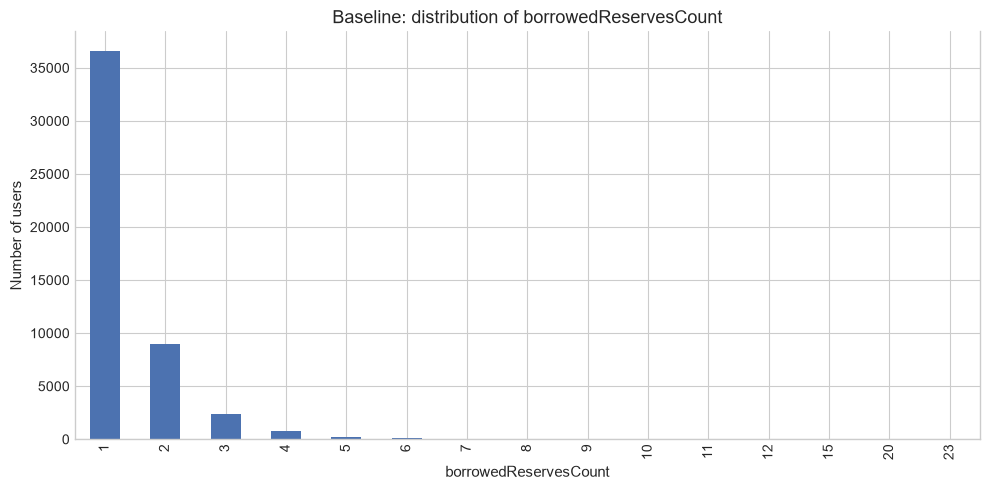

In [25]:
def classify_nested_column(series: pd.Series) -> str:
    """Return a short label for the first non-null nested Python type."""
    sample = series.dropna().iloc[0] if series.notna().any() else None
    if isinstance(sample, list):
        return f"list (example length={len(sample)})"
    if isinstance(sample, dict):
        return f"dict (keys={list(sample.keys())})"
    return type(sample).__name__


print("Nested / object columns in users_df:")
for column in users_df.columns:
    if users_df[column].dtype == "object":
        print(f"  - {column}: {classify_nested_column(users_df[column])}")

n_users = len(users_df)
n_with_reserves = users_df["reserves"].map(lambda value: isinstance(value, list) and len(value) > 0).sum()
n_live_debt = (users_df["borrowedReservesCount"] > 0).sum()

history_counts = {"aTokenBalanceHistory": 0, "vTokenBalanceHistory": 0, "sTokenBalanceHistory": 0}
n_reserves_total = 0
for reserves in users_df["reserves"]:
    if not isinstance(reserves, list):
        continue
    n_reserves_total += len(reserves)
    for reserve in reserves:
        if not isinstance(reserve, dict):
            continue
        for history_key in history_counts:
            history = reserve.get(history_key, [])
            if isinstance(history, list) and len(history) > 0:
                history_counts[history_key] += 1

print()
print(f"Users: {n_users:,}")
print(f"Users with borrowedReservesCount > 0: {n_live_debt:,}")
print(f"Users with a non-empty reserves list: {n_with_reserves:,}")
print(f"Total nested reserve records: {n_reserves_total:,}")
print("Reserves with non-empty 30-day histories:")
for history_key, count in history_counts.items():
    print(f"  - {history_key}: {count:,}")

live_debt_mask = users_df["borrowedReservesCount"] > 0
if not live_debt_mask.any():
    raise ValueError("No user with borrowedReservesCount > 0 was found in the baseline extract.")

example_user = users_df.loc[live_debt_mask].iloc[0]
example_reserves = example_user["reserves"] if isinstance(example_user["reserves"], list) else []

print()
print("Example borrower with live debt (borrowedReservesCount > 0):")
print(f"  id: {example_user['id']}")
print(f"  borrowedReservesCount: {example_user['borrowedReservesCount']}")
print(f"  eModeCategoryId: {example_user.get('eModeCategoryId')}")
print(f"  n_reserves: {len(example_reserves)}")

if example_reserves:
    example_reserve = example_reserves[0]
    reserve_meta = example_reserve.get("reserve", {})
    print()
    print("First nested reserve (structural sample):")
    print(f"  symbol: {reserve_meta.get('symbol')}")
    print(f"  currentATokenBalance: {example_reserve.get('currentATokenBalance')}")
    print(f"  currentVariableDebt: {example_reserve.get('currentVariableDebt')}")
    print(f"  currentTotalDebt: {example_reserve.get('currentTotalDebt')}")
    print(f"  len(aTokenBalanceHistory): {len(example_reserve.get('aTokenBalanceHistory') or [])}")
    print(f"  len(vTokenBalanceHistory): {len(example_reserve.get('vTokenBalanceHistory') or [])}")
    print(f"  len(sTokenBalanceHistory): {len(example_reserve.get('sTokenBalanceHistory') or [])}")

fig, ax = plt.subplots()
users_df["borrowedReservesCount"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#4C72B0"
)
ax.set_title("Baseline: distribution of borrowedReservesCount")
ax.set_xlabel("borrowedReservesCount")
ax.set_ylabel("Number of users")
plt.tight_layout()
plt.show()

## 6. Flatten nested histories into a longitudinal panel

Each borrower stores collateral and variable-debt paths as **separate nested lists** (`aTokenBalanceHistory`, `vTokenBalanceHistory`) under `reserves`. Markov calibration needs a **long panel**: one row per `(user_id, reserve_symbol, timestamp)`.

**Constant-state rule.** The Graph only emits a history point when the scaled balance changes. If `currentATokenBalance` or `currentVariableDebt` is strictly greater than zero but the matching history list is empty, the position was live and **unchanged** over the 30-day window. Those balances are inferred at the window start and window end timestamps so the panel spans the full valuation interval.

Idle reserves (zero current balances and empty histories) are dropped. Collateral and debt series are aligned on the union of timestamps, with last-observation-carried-forward within each user-reserve.

Both scenarios are flattened into `flat_panels = {'baseline': ..., 'stress': ...}`.

In [26]:
def _as_int(value) -> int:
    """Coerce GraphQL numeric strings to int; missing values become 0."""
    if value in (None, ""):
        return 0
    return int(value)


def _history_by_timestamp(history, balance_key: str) -> dict[int, int]:
    """Map Unix timestamps to raw token balances (last write wins)."""
    points: dict[int, int] = {}
    if not history:
        return points
    for item in history:
        timestamp = _as_int(item.get("timestamp"))
        points[timestamp] = _as_int(item.get(balance_key))
    return points


def flatten_user_reserve_histories(
    users: list,
    window_start: int,
    window_end: int,
) -> list[tuple]:
    """Unnest Aave v3 user reserves into a longitudinal list of tuples.

    For each user-reserve the function:
    1. Collects aToken (collateral) and vToken (variable debt) history points.
    2. If a live current balance has an empty history, fills that constant
       balance at ``window_start`` and ``window_end``.
    3. Walks the union of timestamps and forward-fills the other side.

    Returns
    -------
    list[tuple]
        ``(user_id, timestamp, reserve_symbol, aToken_balance, vToken_balance)``
        with balances scaled by the reserve decimals.
    """
    rows: list[tuple] = []
    append = rows.append

    for user in users:
        user_id = user.get("id")
        for reserve in user.get("reserves") or ():
            meta = reserve.get("reserve") or {}
            symbol = meta.get("symbol") or "UNKNOWN"
            decimals = _as_int(meta.get("decimals")) or 18
            scale = 10 ** decimals

            a_map = _history_by_timestamp(
                reserve.get("aTokenBalanceHistory"),
                "currentATokenBalance",
            )
            v_map = _history_by_timestamp(
                reserve.get("vTokenBalanceHistory"),
                "currentVariableDebt",
            )
            a_now = _as_int(reserve.get("currentATokenBalance"))
            v_now = _as_int(reserve.get("currentVariableDebt"))

            # Constant collateral: live balance, no change events in the window.
            if not a_map and a_now > 0:
                a_map[window_start] = a_now
                a_map[window_end] = a_now
            # Constant variable debt: live balance, no change events in the window.
            if not v_map and v_now > 0:
                v_map[window_start] = v_now
                v_map[window_end] = v_now

            if not a_map and not v_map:
                continue

            last_a = 0
            last_v = 0
            for timestamp in sorted(a_map.keys() | v_map.keys()):
                if timestamp in a_map:
                    last_a = a_map[timestamp]
                if timestamp in v_map:
                    last_v = v_map[timestamp]
                append(
                    (
                        user_id,
                        timestamp,
                        symbol,
                        last_a / scale,
                        last_v / scale,
                    )
                )

    return rows

In [27]:
def payload_to_flat_panel(payload: dict) -> pd.DataFrame:
    """Flatten one Graph payload into a user-reserve timestamp panel."""
    window_start = int(payload["start_timestamp"])
    window_end = int(payload["end_timestamp"])
    rows = flatten_user_reserve_histories(
        payload["users"],
        window_start=window_start,
        window_end=window_end,
    )
    panel = pd.DataFrame(
        rows,
        columns=[
            "user_id",
            "timestamp",
            "reserve_symbol",
            "aToken_balance",
            "vToken_balance",
        ],
    )
    panel["date"] = pd.to_datetime(panel["timestamp"], unit="s", utc=True)
    return panel[
        [
            "user_id",
            "timestamp",
            "date",
            "reserve_symbol",
            "aToken_balance",
            "vToken_balance",
        ]
    ]


flat_panels: dict[str, pd.DataFrame] = {}

for scenario_key, payload in payloads.items():
    panel = payload_to_flat_panel(payload)
    window_start = int(payload["start_timestamp"])
    window_end = int(payload["end_timestamp"])
    n_constant_boundary = int(
        ((panel["timestamp"] == window_start) | (panel["timestamp"] == window_end)).sum()
    )
    print(f"[{scenario_key}] window=[{window_start}, {window_end}]")
    print(f"  flattened rows: {len(panel):,}")
    print(f"  unique users: {panel['user_id'].nunique():,}")
    print(f"  unique reserves: {panel['reserve_symbol'].nunique():,}")
    print(f"  rows at window start or end (includes inferred constants): {n_constant_boundary:,}")
    flat_panels[scenario_key] = panel

flat_panel_base = flat_panels["baseline"]
flat_panel_stress = flat_panels["stress"]
flat_panel_df = flat_panel_base  # alias for the baseline verification cell below

[baseline] window=[1707868800, 1710460800]
  flattened rows: 223,930
  unique users: 45,170
  unique reserves: 65
  rows at window start or end (includes inferred constants): 211,950
[stress] window=[1720224000, 1722816000]
  flattened rows: 230,955
  unique users: 45,245
  unique reserves: 65
  rows at window start or end (includes inferred constants): 209,522


## 7. Flattened panel verification

Sort each scenario by `user_id` and `timestamp`, then inspect shape, dtypes, and the first ten rows.

In [28]:
for scenario_key, panel in flat_panels.items():
    flat_panels[scenario_key] = (
        panel.sort_values(["user_id", "timestamp"], kind="mergesort").reset_index(drop=True)
    )
    print(f"=== {scenario_key} ===")
    print(f"shape: {flat_panels[scenario_key].shape}")
    print()
    flat_panels[scenario_key].info()
    print()
    display(flat_panels[scenario_key].head(10))
    print()

flat_panel_base = flat_panels["baseline"]
flat_panel_stress = flat_panels["stress"]
flat_panel_df = flat_panel_base

=== baseline ===
shape: (223930, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223930 entries, 0 to 223929
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   user_id         223930 non-null  object             
 1   timestamp       223930 non-null  int64              
 2   date            223930 non-null  datetime64[ns, UTC]
 3   reserve_symbol  223930 non-null  object             
 4   aToken_balance  223930 non-null  float64            
 5   vToken_balance  223930 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(1), object(2)
memory usage: 10.3+ MB



,user_id,timestamp,date,reserve_symbol,aToken_balance,vToken_balance
0,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,1707868800,2024-02-14 00:00:00+00:00,WETH,0.000000e+00,2.000000e-18
1,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,1710460800,2024-03-15 00:00:00+00:00,WETH,0.000000e+00,2.000000e-18
2,0x000000000000bb1b11e5ac8099e92e366b64c133,1707868800,2024-02-14 00:00:00+00:00,WBTC,1.000000e-08,0.000000e+00
3,0x000000000000bb1b11e5ac8099e92e366b64c133,1707868800,2024-02-14 00:00:00+00:00,USDC,0.000000e+00,1.268000e-03
4,0x000000000000bb1b11e5ac8099e92e366b64c133,1707868800,2024-02-14 00:00:00+00:00,WETH,5.050000e-07,0.000000e+00
5,0x000000000000bb1b11e5ac8099e92e366b64c133,1707868800,2024-02-14 00:00:00+00:00,USDT,9.997000e-03,0.000000e+00
6,0x000000000000bb1b11e5ac8099e92e366b64c133,1710460800,2024-03-15 00:00:00+00:00,WBTC,1.000000e-08,0.000000e+00
7,0x000000000000bb1b11e5ac8099e92e366b64c133,1710460800,2024-03-15 00:00:00+00:00,USDC,0.000000e+00,1.268000e-03
8,0x000000000000bb1b11e5ac8099e92e366b64c133,1710460800,2024-03-15 00:00:00+00:00,WETH,5.050000e-07,0.000000e+00
9,0x000000000000bb1b11e5ac8099e92e366b64c133,1710460800,2024-03-15 00:00:00+00:00,USDT,9.997000e-03,0.000000e+00



=== stress ===
shape: (230955, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230955 entries, 0 to 230954
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   user_id         230955 non-null  object             
 1   timestamp       230955 non-null  int64              
 2   date            230955 non-null  datetime64[ns, UTC]
 3   reserve_symbol  230955 non-null  object             
 4   aToken_balance  230955 non-null  float64            
 5   vToken_balance  230955 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(1), object(2)
memory usage: 10.6+ MB



,user_id,timestamp,date,reserve_symbol,aToken_balance,vToken_balance
0,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,1720224000,2024-07-06 00:00:00+00:00,WETH,0.000000e+00,2.000000e-18
1,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,1722816000,2024-08-05 00:00:00+00:00,WETH,0.000000e+00,2.000000e-18
2,0x000000000000bb1b11e5ac8099e92e366b64c133,1720224000,2024-07-06 00:00:00+00:00,WBTC,1.000000e-08,0.000000e+00
3,0x000000000000bb1b11e5ac8099e92e366b64c133,1720224000,2024-07-06 00:00:00+00:00,USDC,0.000000e+00,1.268000e-03
4,0x000000000000bb1b11e5ac8099e92e366b64c133,1720224000,2024-07-06 00:00:00+00:00,WETH,5.050000e-07,0.000000e+00
5,0x000000000000bb1b11e5ac8099e92e366b64c133,1720224000,2024-07-06 00:00:00+00:00,USDT,9.997000e-03,0.000000e+00
6,0x000000000000bb1b11e5ac8099e92e366b64c133,1722816000,2024-08-05 00:00:00+00:00,WBTC,1.000000e-08,0.000000e+00
7,0x000000000000bb1b11e5ac8099e92e366b64c133,1722816000,2024-08-05 00:00:00+00:00,USDC,0.000000e+00,1.268000e-03
8,0x000000000000bb1b11e5ac8099e92e366b64c133,1722816000,2024-08-05 00:00:00+00:00,WETH,5.050000e-07,0.000000e+00
9,0x000000000000bb1b11e5ac8099e92e366b64c133,1722816000,2024-08-05 00:00:00+00:00,USDT,9.997000e-03,0.000000e+00


## 8. Market data ingestion

For each scenario folder, load the three Binance daily extracts (`binance_prices_eth.csv`, `binance_prices_uni.csv`, `binance_prices_btc.csv`) and keep the **close** as the USD proxy.

Asset-to-ticker assignment uses `PRICE_PROXIES` from `src.utils.config` (ETH-correlated LSTs inherit the ETHUSDT close; WBTC inherits BTCUSDT; UNI uses UNIUSDT). Every symbol in `STABLECOINS` is priced at a strict **$1.00**.

In [29]:
BINANCE_CSV_BY_TICKER = {
    "ETHUSDT": "binance_prices_eth.csv",
    "UNIUSDT": "binance_prices_uni.csv",
    "BTCUSDT": "binance_prices_btc.csv",
}

STABLECOIN_SET = set(STABLECOINS)
ETH_CORE = set(LST_ASSETS) | {"WETH", "ETH"}
PROFILE_A_REMAINDER = STABLECOIN_SET | {"WBTC"}
PROFILE_B_CORE = {"UNI", "LINK"}
PROFILE_B_REMAINDER = STABLECOIN_SET | {"WETH", "ETH", "WBTC"} | set(LST_ASSETS)
DOMINANCE_THRESHOLD = 0.85
DUST_USD = 1e-4


def load_scenario_close_prices(folder_name: str) -> pd.DataFrame:
    """Load Binance daily closes for one scenario, keyed by (date, ticker)."""
    frames = []
    scenario_dir = RAW_DATA_DIR / folder_name
    for ticker, filename in BINANCE_CSV_BY_TICKER.items():
        csv_path = scenario_dir / filename
        if not csv_path.exists():
            raise FileNotFoundError(f"Missing Binance extract: {csv_path.resolve()}")
        frame = pd.read_csv(csv_path, parse_dates=["date"])
        frame["date"] = pd.to_datetime(frame["date"], utc=True).dt.normalize()
        frame["ticker"] = ticker
        frames.append(frame[["date", "ticker", "close"]])
    prices = pd.concat(frames, ignore_index=True)
    prices["close"] = pd.to_numeric(prices["close"], errors="raise")
    return prices.drop_duplicates(subset=["date", "ticker"], keep="last")


price_maps: dict[str, pd.DataFrame] = {}
for folder_name in SCENARIO_DIRS:
    scenario_key = SCENARIO_KEY[folder_name]
    prices = load_scenario_close_prices(folder_name)
    price_maps[scenario_key] = prices
    print(f"[{scenario_key}] close-price rows: {len(prices):,}")
    print(prices.groupby("ticker")["date"].agg(["min", "max", "count"]))
    print()

[baseline] close-price rows: 2,193
                              min                       max  count
ticker                                                            
BTCUSDT 2022-03-16 00:00:00+00:00 2024-03-15 00:00:00+00:00    731
ETHUSDT 2022-03-16 00:00:00+00:00 2024-03-15 00:00:00+00:00    731
UNIUSDT 2022-03-16 00:00:00+00:00 2024-03-15 00:00:00+00:00    731

[stress] close-price rows: 2,193
                              min                       max  count
ticker                                                            
BTCUSDT 2022-08-06 00:00:00+00:00 2024-08-05 00:00:00+00:00    731
ETHUSDT 2022-08-06 00:00:00+00:00 2024-08-05 00:00:00+00:00    731
UNIUSDT 2022-08-06 00:00:00+00:00 2024-08-05 00:00:00+00:00    731



## 9. Daily USD valuation

Sparse Graph snapshots are expanded onto the scenario calendar so that **constant token balances still revalue daily** with Binance closes. Then:

- `collateral_usd = aToken_balance * price`
- `debt_usd = vToken_balance * price`

Stablecoins receive `price = 1.0`. All other symbols take `PRICE_PROXIES[symbol]` and the matching scenario close. Positions with a positive token balance but no proxy are left unpriced and later fail the purity screens.

In [30]:
def expand_to_daily_panel(
    panel: pd.DataFrame,
    window_start: int,
    window_end: int,
) -> pd.DataFrame:
    """Forward-fill user-reserve balances onto every UTC calendar day in the window."""
    start = pd.to_datetime(window_start, unit="s", utc=True).normalize()
    end = pd.to_datetime(window_end, unit="s", utc=True).normalize()
    calendar = pd.DataFrame({"date": pd.date_range(start, end, freq="D", tz="UTC")})
    pairs = panel[["user_id", "reserve_symbol"]].drop_duplicates()
    grid = pairs.merge(calendar, how="cross")

    sparse = (
        panel.assign(date=lambda df: df["date"].dt.normalize())
        .sort_values(["user_id", "reserve_symbol", "date", "timestamp"])
        .groupby(["user_id", "reserve_symbol", "date"], as_index=False)
        .agg(
            aToken_balance=("aToken_balance", "last"),
            vToken_balance=("vToken_balance", "last"),
        )
    )
    daily = grid.merge(sparse, on=["user_id", "reserve_symbol", "date"], how="left")
    daily = daily.sort_values(["user_id", "reserve_symbol", "date"], kind="mergesort")
    daily[["aToken_balance", "vToken_balance"]] = daily.groupby(
        ["user_id", "reserve_symbol"], sort=False
    )[["aToken_balance", "vToken_balance"]].ffill()
    daily = daily.dropna(subset=["aToken_balance", "vToken_balance"], how="all")
    live = (daily["aToken_balance"] > 0) | (daily["vToken_balance"] > 0)
    return daily.loc[live].copy()


def value_panel_usd(daily_panel: pd.DataFrame, prices: pd.DataFrame) -> pd.DataFrame:
    """Attach daily USD prices and compute collateral_usd / debt_usd."""
    valued = daily_panel.copy()
    valued["ticker"] = valued["reserve_symbol"].map(PRICE_PROXIES)
    valued["is_stablecoin"] = valued["reserve_symbol"].isin(STABLECOIN_SET)
    valued = valued.merge(prices, on=["date", "ticker"], how="left")
    valued["price"] = valued["close"]
    valued.loc[valued["is_stablecoin"], "price"] = 1.0
    valued["collateral_usd"] = valued["aToken_balance"] * valued["price"]
    valued["debt_usd"] = valued["vToken_balance"] * valued["price"]
    return valued


usd_panels: dict[str, pd.DataFrame] = {}

for folder_name in SCENARIO_DIRS:
    scenario_key = SCENARIO_KEY[folder_name]
    payload = payloads[scenario_key]
    daily = expand_to_daily_panel(
        flat_panels[scenario_key],
        window_start=int(payload["start_timestamp"]),
        window_end=int(payload["end_timestamp"]),
    )
    valued = value_panel_usd(daily, price_maps[scenario_key])
    usd_panels[scenario_key] = valued
    n_unpriced = int(
        (
            (~valued["is_stablecoin"])
            & valued["price"].isna()
            & ((valued["aToken_balance"] > 0) | (valued["vToken_balance"] > 0))
        ).sum()
    )
    print(f"[{scenario_key}] daily USD rows: {len(valued):,}")
    print(f"  unique users: {valued['user_id'].nunique():,}")
    print(f"  unpriced live rows (no PRICE_PROXIES match): {n_unpriced:,}")
    display(valued.head())
    print()

[baseline] daily USD rows: 3,348,188
  unique users: 45,157
  unpriced live rows (no PRICE_PROXIES match): 660,384


,user_id,reserve_symbol,date,aToken_balance,vToken_balance,ticker,is_stablecoin,close,price,collateral_usd,debt_usd
0,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,WETH,2024-02-14 00:00:00+00:00,0.0,2.000000e-18,ETHUSDT,False,2774.81,2774.81,0.0,5.549620e-15
1,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,WETH,2024-02-15 00:00:00+00:00,0.0,2.000000e-18,ETHUSDT,False,2822.59,2822.59,0.0,5.645180e-15
2,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,WETH,2024-02-16 00:00:00+00:00,0.0,2.000000e-18,ETHUSDT,False,2801.80,2801.80,0.0,5.603600e-15
3,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,WETH,2024-02-17 00:00:00+00:00,0.0,2.000000e-18,ETHUSDT,False,2785.93,2785.93,0.0,5.571860e-15
4,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,WETH,2024-02-18 00:00:00+00:00,0.0,2.000000e-18,ETHUSDT,False,2881.20,2881.20,0.0,5.762400e-15



[stress] daily USD rows: 3,334,565
  unique users: 45,226
  unpriced live rows (no PRICE_PROXIES match): 660,267


,user_id,reserve_symbol,date,aToken_balance,vToken_balance,ticker,is_stablecoin,close,price,collateral_usd,debt_usd
0,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,WETH,2024-07-06 00:00:00+00:00,0.0,2.000000e-18,ETHUSDT,False,3066.83,3066.83,0.0,6.133660e-15
1,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,WETH,2024-07-07 00:00:00+00:00,0.0,2.000000e-18,ETHUSDT,False,2931.00,2931.00,0.0,5.862000e-15
2,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,WETH,2024-07-08 00:00:00+00:00,0.0,2.000000e-18,ETHUSDT,False,3019.01,3019.01,0.0,6.038020e-15
3,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,WETH,2024-07-09 00:00:00+00:00,0.0,2.000000e-18,ETHUSDT,False,3066.65,3066.65,0.0,6.133300e-15
4,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,WETH,2024-07-10 00:00:00+00:00,0.0,2.000000e-18,ETHUSDT,False,3101.05,3101.05,0.0,6.202100e-15


## 10. Aggregation and actuarial dominance filters

Positions are summed to the `(user_id, date)` level. Sub-microdollar residuals (`DUST_USD`) are treated as zero so leftover wei does not contaminate purity tests.

**Debt rule:** 100% of `total_debt_usd` must be in `STABLECOINS`.

**Profile A (ETH dominance):** at least 85% of `total_collateral_usd` in `WETH` or `LST_ASSETS`. The residual (at most 15%) may only be `STABLECOINS` or `WBTC`.

**Profile B (UNI+LINK high-risk dominance):** at least 85% of `total_collateral_usd` in the high-risk basket `UNI` + `LINK`, i.e. `(collateral_UNI_usd + collateral_LINK_usd) / total_collateral_usd >= 0.85`. The residual (at most 15%) may only be lower-volatility assets: `STABLECOINS`, `WETH`, `LST_ASSETS`, or `WBTC`.

A wallet is retained if it satisfies Profile A and/or Profile B on **at least one** calendar day. The Health Factor panel below keeps only those qualifying user-days.

In [31]:
# Profile B core: joint high-risk basket. Remainder is unchanged (lower-volatility assets only).
PROFILE_B_CORE = {"UNI", "LINK"}
FOLDER_BY_SCENARIO = {key: folder for folder, key in SCENARIO_KEY.items()}


def attach_link_usd_prices(usd_panel: pd.DataFrame, folder_name: str) -> pd.DataFrame:
    """Fill LINK USD using binance_prices_link.csv so LINK can enter the Profile B numerator."""
    csv_path = RAW_DATA_DIR / folder_name / "binance_prices_link.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing Binance extract: {csv_path.resolve()}")
    link_prices = pd.read_csv(csv_path, parse_dates=["date"])
    link_prices["date"] = pd.to_datetime(link_prices["date"], utc=True).dt.normalize()
    link_prices = link_prices[["date", "close"]].rename(columns={"close": "link_close"})
    panel = usd_panel.merge(link_prices, on="date", how="left")
    link_mask = panel["reserve_symbol"].eq("LINK")
    panel.loc[link_mask, "ticker"] = "LINKUSDT"
    panel.loc[link_mask, "price"] = panel.loc[link_mask, "link_close"]
    panel.loc[link_mask, "collateral_usd"] = (
        panel.loc[link_mask, "aToken_balance"] * panel.loc[link_mask, "price"]
    )
    panel.loc[link_mask, "debt_usd"] = (
        panel.loc[link_mask, "vToken_balance"] * panel.loc[link_mask, "price"]
    )
    return panel.drop(columns=["link_close"])


for scenario_key in list(usd_panels):
    usd_panels[scenario_key] = attach_link_usd_prices(
        usd_panels[scenario_key], FOLDER_BY_SCENARIO[scenario_key]
    )


def apply_dust_floor(usd_panel: pd.DataFrame) -> pd.DataFrame:
    """Zero out sub-microdollar USD residuals from integer wei dust."""
    cleaned = usd_panel.copy()
    cleaned["collateral_usd"] = cleaned["collateral_usd"].fillna(0.0)
    cleaned["debt_usd"] = cleaned["debt_usd"].fillna(0.0)
    cleaned.loc[cleaned["collateral_usd"] < DUST_USD, "collateral_usd"] = 0.0
    cleaned.loc[cleaned["debt_usd"] < DUST_USD, "debt_usd"] = 0.0
    return cleaned


def classify_dominance(usd_panel: pd.DataFrame) -> pd.DataFrame:
    """Return one row per (user_id, date) with Profile A / B flags and USD totals."""
    work = apply_dust_floor(usd_panel)
    work["has_unpriced_collateral"] = (
        (~work["is_stablecoin"])
        & work["price"].isna()
        & (work["aToken_balance"] > 0)
    )

    totals = work.groupby(["user_id", "date"], as_index=False).agg(
        total_collateral_usd=("collateral_usd", "sum"),
        total_debt_usd=("debt_usd", "sum"),
        has_unpriced_collateral=("has_unpriced_collateral", "any"),
    )

    eth_core_usd = (
        work.loc[work["reserve_symbol"].isin(ETH_CORE)]
        .groupby(["user_id", "date"])["collateral_usd"]
        .sum()
        .rename("eth_core_collateral_usd")
    )
    high_risk_usd = (
        work.loc[work["reserve_symbol"].isin(PROFILE_B_CORE)]
        .groupby(["user_id", "date"])["collateral_usd"]
        .sum()
        .rename("high_risk_collateral_usd")
    )
    stable_debt_usd = (
        work.loc[work["reserve_symbol"].isin(STABLECOIN_SET)]
        .groupby(["user_id", "date"])["debt_usd"]
        .sum()
        .rename("stable_debt_usd")
    )

    a_disallowed = work.loc[
        (work["collateral_usd"] > 0)
        & ~work["reserve_symbol"].isin(ETH_CORE | PROFILE_A_REMAINDER)
    ][["user_id", "date"]].drop_duplicates()
    a_disallowed["profile_a_disallowed"] = True

    b_disallowed = work.loc[
        (work["collateral_usd"] > 0)
        & ~work["reserve_symbol"].isin(PROFILE_B_CORE | PROFILE_B_REMAINDER)
    ][["user_id", "date"]].drop_duplicates()
    b_disallowed["profile_b_disallowed"] = True

    classified = (
        totals.merge(eth_core_usd, on=["user_id", "date"], how="left")
        .merge(high_risk_usd, on=["user_id", "date"], how="left")
        .merge(stable_debt_usd, on=["user_id", "date"], how="left")
        .merge(a_disallowed, on=["user_id", "date"], how="left")
        .merge(b_disallowed, on=["user_id", "date"], how="left")
    )
    classified["eth_core_collateral_usd"] = classified["eth_core_collateral_usd"].fillna(0.0)
    classified["high_risk_collateral_usd"] = classified["high_risk_collateral_usd"].fillna(0.0)
    classified["stable_debt_usd"] = classified["stable_debt_usd"].fillna(0.0)
    classified["eth_share"] = (
        classified["eth_core_collateral_usd"] / classified["total_collateral_usd"].replace(0, pd.NA)
    ).fillna(0.0)
    classified["high_risk_share"] = (
        classified["high_risk_collateral_usd"] / classified["total_collateral_usd"].replace(0, pd.NA)
    ).fillna(0.0)

    classified["profile_a_disallowed"] = classified["profile_a_disallowed"].fillna(False).astype(bool)
    classified["profile_b_disallowed"] = classified["profile_b_disallowed"].fillna(False).astype(bool)

    debt_ok = (classified["total_debt_usd"] > 0) & (
        classified["stable_debt_usd"] >= classified["total_debt_usd"] * (1.0 - 1e-8)
    )
    collat_ok = classified["total_collateral_usd"] > 0
    priced_ok = ~classified["has_unpriced_collateral"]

    classified["is_profile_a"] = (
        debt_ok
        & collat_ok
        & priced_ok
        & ~classified["profile_a_disallowed"]
        & (classified["eth_share"] >= DOMINANCE_THRESHOLD)
    )
    classified["is_profile_b"] = (
        debt_ok
        & collat_ok
        & priced_ok
        & ~classified["profile_b_disallowed"]
        & (classified["high_risk_share"] >= DOMINANCE_THRESHOLD)
    )
    return classified


dominance_panels: dict[str, pd.DataFrame] = {}
eligible_wallets: dict[str, set] = {}

for scenario_key, usd_panel in usd_panels.items():
    classified = classify_dominance(usd_panel)
    dominance_panels[scenario_key] = classified
    surviving = classified.loc[
        classified["is_profile_a"] | classified["is_profile_b"], "user_id"
    ].unique()
    eligible_wallets[scenario_key] = set(surviving)
    print(f"[{scenario_key}] user-days: {len(classified):,}")
    print(f"  Profile A user-days: {int(classified['is_profile_a'].sum()):,}")
    print(f"  Profile B user-days: {int(classified['is_profile_b'].sum()):,}")
    print(f"  wallets passing on at least one day: {len(surviving):,}")
    print()

profile_b_wallet_labels = []
for scenario_key, classified in dominance_panels.items():
    n_profile_b = classified.loc[classified["is_profile_b"], "user_id"].nunique()
    profile_b_wallet_labels.extend([scenario_key] * n_profile_b)
    print(f"[{scenario_key}] Profile B wallets (UNI+LINK dominance): {n_profile_b:,}")

print()
print("Profile B surviving wallets under joint UNI+LINK dominance (value_counts):")
print(pd.Series(profile_b_wallet_labels, name="scenario").value_counts())

C:\Users\facun\AppData\Local\Temp\ipykernel_1476\1648918170.py:101: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0.0)
C:\Users\facun\AppData\Local\Temp\ipykernel_1476\1648918170.py:104: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0.0)
C:\Users\facun\AppData\Local\Temp\ipykernel_1476\1648918170.py:106: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_

[baseline] user-days: 1,394,561
  Profile A user-days: 238,218
  Profile B user-days: 17,081
  wallets passing on at least one day: 8,570



C:\Users\facun\AppData\Local\Temp\ipykernel_1476\1648918170.py:101: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0.0)
C:\Users\facun\AppData\Local\Temp\ipykernel_1476\1648918170.py:104: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0.0)


[stress] user-days: 1,391,225
  Profile A user-days: 236,562
  Profile B user-days: 16,238
  wallets passing on at least one day: 8,663

[baseline] Profile B wallets (UNI+LINK dominance): 592
[stress] Profile B wallets (UNI+LINK dominance): 576

Profile B surviving wallets under joint UNI+LINK dominance (value_counts):
scenario
baseline    592
stress      576
Name: count, dtype: int64


C:\Users\facun\AppData\Local\Temp\ipykernel_1476\1648918170.py:106: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  classified["profile_a_disallowed"] = classified["profile_a_disallowed"].fillna(False).astype(bool)
C:\Users\facun\AppData\Local\Temp\ipykernel_1476\1648918170.py:107: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  classified["profile_b_disallowed"] = classified["profile_b_disallowed"].fillna(False).astype(bool)


## 11. Empirical Health Factor

For qualifying user-days in both scenarios:

$$
HF_t = \frac{\sum_i (\text{Collateral USD}_{i,t} \times LT_i)}{\text{Total Debt USD}_t}
$$

`LT_i` is taken **only** from `LIQUIDATION_THRESHOLDS`. Symbols missing from that map — including any stablecoin not listed explicitly — use `LIQUIDATION_THRESHOLDS['DEFAULT']`.

If a user-day matches both profiles (should be rare), it is labelled `A+B`. Wallet counts below use `.value_counts()` on the distinct profile labels of surviving wallets.

In [32]:
def liquidation_threshold(symbol: str) -> float:
    """Look up LT from config; stablecoins and unknown assets use DEFAULT."""
    if symbol in LIQUIDATION_THRESHOLDS:
        return LIQUIDATION_THRESHOLDS[symbol]
    if symbol in STABLECOIN_SET:
        return LIQUIDATION_THRESHOLDS["DEFAULT"]
    return LIQUIDATION_THRESHOLDS["DEFAULT"]


def assign_profile_label(is_profile_a: bool, is_profile_b: bool) -> str:
    if is_profile_a and is_profile_b:
        return "A+B"
    if is_profile_a:
        return "A"
    if is_profile_b:
        return "B"
    return ""


def compute_health_factor_panel(
    usd_panel: pd.DataFrame,
    classified: pd.DataFrame,
) -> pd.DataFrame:
    """HF for user-days that satisfy Profile A and/or Profile B."""
    qualifying = classified.loc[
        classified["is_profile_a"] | classified["is_profile_b"],
        [
            "user_id",
            "date",
            "total_collateral_usd",
            "total_debt_usd",
            "is_profile_a",
            "is_profile_b",
        ],
    ].copy()
    qualifying["profile"] = [
        assign_profile_label(is_a, is_b)
        for is_a, is_b in zip(qualifying["is_profile_a"], qualifying["is_profile_b"])
    ]

    asset_level = apply_dust_floor(usd_panel)
    asset_level["lt"] = asset_level["reserve_symbol"].map(liquidation_threshold)
    asset_level["threshold_weighted_collateral_usd"] = (
        asset_level["collateral_usd"] * asset_level["lt"]
    )
    weighted = (
        asset_level.groupby(["user_id", "date"], as_index=False)[
            "threshold_weighted_collateral_usd"
        ].sum()
    )

    hf = qualifying.merge(weighted, on=["user_id", "date"], how="left")
    hf["health_factor"] = hf["threshold_weighted_collateral_usd"] / hf["total_debt_usd"]
    hf = hf.sort_values(["profile", "user_id", "date"], kind="mergesort").reset_index(drop=True)
    return hf[
        [
            "user_id",
            "date",
            "profile",
            "total_collateral_usd",
            "total_debt_usd",
            "threshold_weighted_collateral_usd",
            "health_factor",
        ]
    ]


hf_panels: dict[str, pd.DataFrame] = {}
wallet_profile_counts: dict[str, pd.Series] = {}

for scenario_key in payloads:
    hf_df = compute_health_factor_panel(usd_panels[scenario_key], dominance_panels[scenario_key])
    hf_df.insert(0, "scenario", scenario_key)
    hf_panels[scenario_key] = hf_df

    wallet_profiles = (
        hf_df.groupby("user_id")["profile"]
        .agg(lambda labels: ",".join(sorted(set(labels))))
        .rename("profile")
    )
    wallet_profile_counts[scenario_key] = wallet_profiles.value_counts()

    print(f"=== {scenario_key} ===")
    print("Pure wallets by profile (value_counts):")
    print(wallet_profile_counts[scenario_key])
    print()
    print(f"HF panel shape: {hf_df.shape}")
    display(hf_df.head())
    print()

hf_panel_df = pd.concat(hf_panels.values(), ignore_index=True)
print("Combined HF panel:")
print(hf_panel_df.shape)
display(hf_panel_df.head())

=== baseline ===
Pure wallets by profile (value_counts):
profile
A      7978
B       588
A,B       4
Name: count, dtype: int64

HF panel shape: (255299, 8)


,scenario,user_id,date,profile,total_collateral_usd,total_debt_usd,threshold_weighted_collateral_usd,health_factor
0,baseline,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-02-14 00:00:00+00:00,A,277.481,31.0,228.921825,7.384575
1,baseline,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-02-15 00:00:00+00:00,A,282.259,31.0,232.863675,7.511731
2,baseline,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-02-16 00:00:00+00:00,A,280.180,31.0,231.148500,7.456403
3,baseline,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-02-17 00:00:00+00:00,A,278.593,31.0,229.839225,7.414169
4,baseline,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-02-18 00:00:00+00:00,A,288.120,31.0,237.699000,7.667710



=== stress ===
Pure wallets by profile (value_counts):
profile
A      8087
B       570
A,B       6
Name: count, dtype: int64

HF panel shape: (252800, 8)


,scenario,user_id,date,profile,total_collateral_usd,total_debt_usd,threshold_weighted_collateral_usd,health_factor
0,stress,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-07-06 00:00:00+00:00,A,306.683,31.0,253.013475,8.161725
1,stress,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-07-07 00:00:00+00:00,A,293.100,31.0,241.807500,7.800242
2,stress,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-07-08 00:00:00+00:00,A,301.901,31.0,249.068325,8.034462
3,stress,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-07-09 00:00:00+00:00,A,306.665,31.0,252.998625,8.161246
4,stress,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-07-10 00:00:00+00:00,A,310.105,31.0,255.836625,8.252794



Combined HF panel:
(508099, 8)


,scenario,user_id,date,profile,total_collateral_usd,total_debt_usd,threshold_weighted_collateral_usd,health_factor
0,baseline,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-02-14 00:00:00+00:00,A,277.481,31.0,228.921825,7.384575
1,baseline,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-02-15 00:00:00+00:00,A,282.259,31.0,232.863675,7.511731
2,baseline,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-02-16 00:00:00+00:00,A,280.180,31.0,231.148500,7.456403
3,baseline,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-02-17 00:00:00+00:00,A,278.593,31.0,229.839225,7.414169
4,baseline,0x000000b9054e79892a1097f4e02e7aa42de22c0c,2024-02-18 00:00:00+00:00,A,288.120,31.0,237.699000,7.667710


## 12. Markov state discretization and daily transitions

This section starts from `hf_panel_df` and builds the empirical transition sample:

1. **Purity filter** — drop hybrid wallets whose profile label is `A,B` (or `A+B`). Keep strictly **A** or **B**.
2. **Current state** — map `health_factor` to `{S2,...,S7}`. Voluntary prepayment `S1` is assigned only as a *next* state.
3. **Next state** — within `(scenario, user_id)`, shift the current state one observation forward. Wallets that exit before the scenario window end are mapped to `S1` (HF > 1) or absorbed in `S7` (HF <= 1). The last day of each 30-day window has no valid t to t+1 transition and is excluded from the counts.

In [33]:
wallet_profile = (
    hf_panel_df.groupby(["scenario", "user_id"], sort=False)["profile"]
    .agg(lambda labels: ",".join(sorted(set(labels))))
    .rename("wallet_profile")
    .reset_index()
)

hybrid_mask = wallet_profile["wallet_profile"].isin(["A,B", "A+B", "B,A"])
n_hybrid_wallets = int(hybrid_mask.sum())
print(f"Hybrid wallets dropped (A,B / A+B): {n_hybrid_wallets:,}")
print(wallet_profile["wallet_profile"].value_counts())
print()

pure_wallets = wallet_profile.loc[
    wallet_profile["wallet_profile"].isin(["A", "B"]),
    ["scenario", "user_id", "wallet_profile"],
]

markov_states_df = hf_panel_df.merge(pure_wallets, on=["scenario", "user_id"], how="inner")
markov_states_df = markov_states_df.loc[markov_states_df["profile"].isin(["A", "B"])].copy()
markov_states_df["profile"] = markov_states_df["wallet_profile"]
markov_states_df = markov_states_df.drop(columns=["wallet_profile"])

print(f"Pure HF rows retained: {len(markov_states_df):,}")
print(f"Pure wallets retained: {markov_states_df.groupby(['scenario', 'user_id']).ngroups:,}")
print(markov_states_df.drop_duplicates(["scenario", "user_id"])["profile"].value_counts())

Hybrid wallets dropped (A,B / A+B): 10
wallet_profile
A      16065
B       1158
A,B       10
Name: count, dtype: int64

Pure HF rows retained: 507,823
Pure wallets retained: 17,223
profile
A    16065
B     1158
Name: count, dtype: int64


## 13. Current-state mapping

`pd.cut` assigns bins with a closed right edge. The single boundary `HF == 1.10` is remapped from `S6` to `S5` so that the target band is `1.10 <= HF < 1.25` and the critical band is `1.0 < HF < 1.10`.

In [34]:
import numpy as np

HF_STATE_BINS = [-np.inf, 1.0, 1.10, 1.25, 1.50, 2.0, np.inf]
HF_STATE_LABELS = ["S7", "S6", "S5", "S4", "S3", "S2"]
STATE_ORDER = ["S1", "S2", "S3", "S4", "S5", "S6", "S7"]


def map_health_factor_to_state(health_factor: pd.Series) -> pd.Series:
    """Map Health Factor to current Markov states S2-S7 (S1 is transition-only)."""
    state = pd.cut(
        health_factor,
        bins=HF_STATE_BINS,
        labels=HF_STATE_LABELS,
        right=True,
        include_lowest=True,
    ).astype("object")
    # pd.cut(right=True) puts HF == 1.10 in S6; the target band starts at 1.10 inclusive.
    state = state.mask(np.isclose(health_factor, 1.10), "S5")
    return pd.Series(state, index=health_factor.index, name="state")


markov_states_df["state"] = map_health_factor_to_state(markov_states_df["health_factor"])

print("Current-state value counts by profile:")
for profile, block in markov_states_df.groupby("profile"):
    print(f"\nProfile {profile}")
    print(block["state"].value_counts().reindex(STATE_ORDER[1:]).fillna(0).astype(int))

Current-state value counts by profile:

Profile A
state
S2    409755
S3     42542
S4      9860
S5      2670
S6      1410
S7      8394
Name: count, dtype: int64

Profile B
state
S2    27057
S3     3682
S4      906
S5      395
S6      178
S7      974
Name: count, dtype: int64


## 14. Longitudinal next state and actuarial right-censoring

Zero collateral and debt rows are dropped upstream, so `total_debt_usd == 0` is not observed. Prepayment (`S1`) is therefore the **dropout** rule: if a wallet's last observed date is strictly before the scenario window end and its last Health Factor is above 1.0, it enters `S1` on `last_date + 1 day`.

Default (`S7`) is the first observed day with `health_factor <= 1.0`.

Each wallet is expanded to a continuous daily index from its first observation through `window_end_date`. The first absorbing hit (`S7` wins a same-day tie) is forward-filled to the window end, which masks restorative liquidations and creates the empirical `S1 -> S1` and `S7 -> S7` transitions. `next_state` is the next day within `(scenario, user_id)`. The window-end day has no `t+1` and is excluded.

In [35]:
scenario_window_end = {
    key: pd.to_datetime(payload["end_datetime_utc"], utc=True).normalize()
    for key, payload in payloads.items()
}

observed = (
    markov_states_df.sort_values(["scenario", "user_id", "date"], kind="mergesort")
    .reset_index(drop=True)
    .copy()
)
observed["date"] = observed["date"].dt.normalize()
observed["window_end_date"] = observed["scenario"].map(scenario_window_end)

wallet_span = (
    observed.groupby(["scenario", "user_id"], sort=False)
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        window_end_date=("window_end_date", "first"),
        profile=("profile", "first"),
    )
    .reset_index()
)
last_obs = (
    observed.groupby(["scenario", "user_id"], sort=False)
    .tail(1)[["scenario", "user_id", "health_factor"]]
    .rename(columns={"health_factor": "last_health_factor"})
)
wallet_span = wallet_span.merge(last_obs, on=["scenario", "user_id"], how="left")

# S7: first observed day with HF <= 1.0.
s7_hits = (
    observed.loc[observed["health_factor"] <= 1.0, ["scenario", "user_id", "date"]]
    .groupby(["scenario", "user_id"], sort=False, as_index=False)["date"]
    .min()
    .rename(columns={"date": "event_date"})
)
s7_hits["absorbing_state"] = "S7"

# S1: dropout before the window end while the last observed HF is still above 1.
# Entry is the calendar day after the last observation (zero balances are absent from the panel).
dropout_mask = (wallet_span["last_date"] < wallet_span["window_end_date"]) & (
    wallet_span["last_health_factor"] > 1.0
)
s1_hits = wallet_span.loc[dropout_mask, ["scenario", "user_id", "last_date"]].copy()
s1_hits["event_date"] = s1_hits["last_date"] + pd.Timedelta(days=1)
s1_hits["absorbing_state"] = "S1"
s1_hits = s1_hits[["scenario", "user_id", "event_date", "absorbing_state"]]

events = pd.concat([s7_hits, s1_hits], ignore_index=True)
events["tie_rank"] = events["absorbing_state"].map({"S7": 0, "S1": 1})
events = events.sort_values(
    ["scenario", "user_id", "event_date", "tie_rank"], kind="mergesort"
)
first_event = events.groupby(["scenario", "user_id"], sort=False, as_index=False).head(1)
first_event = first_event[["scenario", "user_id", "event_date", "absorbing_state"]].copy()

n_s1_dropouts = int(len(s1_hits))
n_s7_hits = int(len(s7_hits))
n_s1_effective = int((first_event["absorbing_state"] == "S1").sum())
n_s7_effective = int((first_event["absorbing_state"] == "S7").sum())

wallet_span["n_days"] = (
    wallet_span["window_end_date"] - wallet_span["first_date"]
).dt.days + 1
wallet_span = wallet_span.loc[wallet_span["n_days"] > 0].copy()

expanded = wallet_span.loc[wallet_span.index.repeat(wallet_span["n_days"])].copy()
expanded["day_offset"] = expanded.groupby(["scenario", "user_id"], sort=False).cumcount()
expanded["date"] = expanded["first_date"] + pd.to_timedelta(expanded["day_offset"], unit="D")

observed_cols = ["scenario", "user_id", "date", "state", "health_factor"]
if "total_debt_usd" in observed.columns:
    observed_cols.append("total_debt_usd")
observed_daily = observed[observed_cols].drop_duplicates(
    ["scenario", "user_id", "date"], keep="last"
)
expanded = expanded.merge(observed_daily, on=["scenario", "user_id", "date"], how="left")
expanded = expanded.merge(first_event, on=["scenario", "user_id"], how="left")
expanded = expanded.sort_values(
    ["scenario", "user_id", "date"], kind="mergesort"
).reset_index(drop=True)

group_keys = ["scenario", "user_id"]
expanded["state_observed"] = expanded.groupby(group_keys, sort=False)["state"].ffill()

hit_mask = expanded["event_date"].notna() & expanded["date"].eq(expanded["event_date"])
expanded["absorbing_hit"] = expanded["absorbing_state"].where(hit_mask)
expanded["absorbing_frozen"] = expanded.groupby(group_keys, sort=False)["absorbing_hit"].ffill()
expanded["final_state"] = expanded["absorbing_frozen"].fillna(expanded["state_observed"])

expanded["is_window_end"] = expanded["date"].eq(expanded["window_end_date"])
expanded["next_state"] = expanded.groupby(group_keys, sort=False)["final_state"].shift(-1)

n_frozen = int(
    expanded["absorbing_frozen"].notna().sum() - hit_mask.sum()
)

markov_states_df = expanded[
    [
        "scenario",
        "user_id",
        "profile",
        "date",
        "health_factor",
        "state_observed",
        "final_state",
        "window_end_date",
        "is_window_end",
        "next_state",
    ]
].copy()
markov_states_df["state"] = markov_states_df["final_state"]

markov_transitions_df = markov_states_df.loc[
    ~markov_states_df["is_window_end"]
    & markov_states_df["state"].notna()
    & markov_states_df["next_state"].notna()
].copy()
markov_transitions_df["transition_pair"] = (
    markov_transitions_df["state"].astype(str)
    + " -> "
    + markov_transitions_df["next_state"].astype(str)
)

print(f"S1 dropout candidates (last date before window end, HF > 1): {n_s1_dropouts:,}")
print(f"S1 first absorbing events after tie-break: {n_s1_effective:,}")
print(f"S7 hits (first day with HF <= 1.0): {n_s7_hits:,}")
print(f"S7 first absorbing events after tie-break: {n_s7_effective:,}")
print(f"Subsequent rows frozen through window end: {n_frozen:,}")
print(f"Window-end rows excluded (no t+1): {int(markov_states_df['is_window_end'].sum()):,}")
print(f"Valid daily transitions (N): {len(markov_transitions_df):,}")
print()
for pair in ("S1 -> S1", "S7 -> S7", "S2 -> S1", "S5 -> S7", "S6 -> S7", "S7 -> S5"):
    n_pair = int((markov_transitions_df["transition_pair"] == pair).sum())
    print(f"  {pair}: {n_pair:,}")

zombie_pairs = [
    "S7 -> S2",
    "S7 -> S3",
    "S7 -> S4",
    "S7 -> S5",
    "S7 -> S6",
    "S1 -> S2",
    "S1 -> S3",
    "S1 -> S4",
    "S1 -> S5",
    "S1 -> S6",
    "S1 -> S7",
    "S7 -> S1",
]
zombie_n = int(markov_transitions_df["transition_pair"].isin(zombie_pairs).sum())
print(f"Contaminated exits from absorbing states (should be 0): {zombie_n:,}")

C:\Users\facun\AppData\Local\Temp\ipykernel_1476\959100397.py:46: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  s1_hits["event_date"] = s1_hits["last_date"] + pd.Timedelta(days=1)


S1 dropout candidates (last date before window end, HF > 1): 385
S1 first absorbing events after tie-break: 381
S7 hits (first day with HF <= 1.0): 634
S7 first absorbing events after tie-break: 634
Subsequent rows frozen through window end: 15,136
Window-end rows excluded (no t+1): 17,223
Valid daily transitions (N): 496,371

  S1 -> S1: 3,589
  S7 -> S7: 11,547
  S2 -> S1: 270
  S5 -> S7: 20
  S6 -> S7: 120
  S7 -> S5: 0
Contaminated exits from absorbing states (should be 0): 0


## 15. Sample-size verification

Cross-sectional `state` counts and empirical `t -> t+1` pair counts (`N`) are reported **separately** for each market regime (`baseline_mar2024`, `stress_aug2024`) and collateral profile (A, B), before assembling the transition matrices.

In [36]:
SCENARIO_LABEL = {
    "baseline": "baseline_mar2024",
    "stress": "stress_aug2024",
}
SCENARIO_PRINT_ORDER = ["baseline", "stress"]
PROFILE_PRINT_ORDER = ["A", "B"]

print("=== Current-state distribution by scenario and profile (value_counts) ===")
for (scenario, profile), block in markov_states_df.groupby(
    ["scenario", "profile"], sort=False
):
    n_wallets = block["user_id"].nunique()
    print(
        f"\n{SCENARIO_LABEL.get(scenario, scenario)} | Profile {profile}  "
        f"(n_rows={len(block):,}, n_wallets={n_wallets:,})"
    )
    print(block["state"].value_counts().reindex(STATE_ORDER[1:]).fillna(0).astype(int))

transition_counts = (
    markov_transitions_df.groupby(["scenario", "profile", "transition_pair"], sort=False)
    .size()
    .rename("n")
    .reset_index()
)

print("\n=== Daily transition pairs by scenario and profile (empirical N) ===")
for scenario in SCENARIO_PRINT_ORDER:
    scenario_label = SCENARIO_LABEL[scenario]
    print(f"\n-------- {scenario_label} --------")
    for profile in PROFILE_PRINT_ORDER:
        block = transition_counts.loc[
            (transition_counts["scenario"] == scenario)
            & (transition_counts["profile"] == profile)
        ].sort_values("n", ascending=False)
        n_total = int(block["n"].sum())
        print(f"\n{scenario_label} | Profile {profile}  (N={n_total:,})")
        if block.empty:
            print("  (no transitions)")
            continue
        pair_counts = block.set_index("transition_pair")["n"]
        print(pair_counts)
        for critical_pair in ("S5 -> S6", "S6 -> S7", "S5 -> S7", "S7 -> S7"):
            n_pair = int(pair_counts.get(critical_pair, 0))
            print(f"  focus {critical_pair}: {n_pair:,}")

print("\n=== Transition-pair counts grouped by scenario, profile, and pair ===")
transition_counts_display = transition_counts.sort_values(
    ["scenario", "profile", "n"], ascending=[True, True, False]
).reset_index(drop=True)
display(transition_counts_display)
print(
    "\nTotal empirical transitions N by scenario and profile:"
)
print(
    markov_transitions_df.groupby(["scenario", "profile"])
    .size()
    .rename("N")
    .reindex(
        pd.MultiIndex.from_product(
            [SCENARIO_PRINT_ORDER, PROFILE_PRINT_ORDER],
            names=["scenario", "profile"],
        )
    )
    .fillna(0)
    .astype(int)
)

=== Current-state distribution by scenario and profile (value_counts) ===

baseline_mar2024 | Profile A  (n_rows=240,210, n_wallets=7,978)
state
S2    207959
S3     20018
S4      4512
S5       838
S6       186
S7      5284
Name: count, dtype: int64

baseline_mar2024 | Profile B  (n_rows=17,596, n_wallets=588)
state
S2    15795
S3      598
S4      164
S5      129
S6       32
S7      457
Name: count, dtype: int64

stress_aug2024 | Profile A  (n_rows=239,276, n_wallets=8,087)
state
S2    202022
S3     22504
S4      5158
S5      1442
S6       561
S7      5582
Name: count, dtype: int64

stress_aug2024 | Profile B  (n_rows=16,512, n_wallets=570)
state
S2    11355
S3     3069
S4      736
S5      258
S6      107
S7      858
Name: count, dtype: int64

=== Daily transition pairs by scenario and profile (empirical N) ===

-------- baseline_mar2024 --------

baseline_mar2024 | Profile A  (N=232,232)
transition_pair
S2 -> S2    200058
S3 -> S3     17509
S7 -> S7      5071
S4 -> S4      3798
S3 -> S

,scenario,profile,transition_pair,n
0,baseline,A,S2 -> S2,200058
1,baseline,A,S3 -> S3,17509
2,baseline,A,S7 -> S7,5071
3,baseline,A,S4 -> S4,3798
4,baseline,A,S3 -> S2,1849
...,...,...,...,...
117,stress,B,S2 -> S4,1
118,stress,B,S2 -> S5,1
119,stress,B,S4 -> S1,1
120,stress,B,S5 -> S1,1



Total empirical transitions N by scenario and profile:
scenario  profile
baseline  A          232232
          B           17008
stress    A          231189
          B           15942
Name: N, dtype: int64


## 16. Empirical transition matrices

Four daily count matrices $\mathbf{N}$ and probability matrices $\mathbf{P}$ are assembled from `transition_pair` in the right-censored panel: one per market regime (`baseline_mar2024`, `stress_aug2024`) and collateral profile (A, B).

Rows and columns follow `STATE_ORDER`. There is **no** identity injection. `S1 -> S1` and `S7 -> S7` are empirical frequencies produced by the forward-filled absorbing paths in Section 14. Each row is normalized by its sum; a row with zero mass stays at zero.

baseline_mar2024 | Profile A (ETH dominance): N=232,232  N(S1->S1)=1,284 P(S1->S1)=1.0000  N(S7->S7)=5,071 P(S7->S7)=1.0000
  row sums: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
baseline_mar2024 | Profile B (UNI+LINK dominance): N=17,008  N(S1->S1)=395 P(S1->S1)=1.0000  N(S7->S7)=437 P(S7->S7)=1.0000
  row sums: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
stress_aug2024 | Profile A (ETH dominance): N=231,189  N(S1->S1)=1,796 P(S1->S1)=1.0000  N(S7->S7)=5,236 P(S7->S7)=1.0000
  row sums: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
stress_aug2024 | Profile B (UNI+LINK dominance): N=15,942  N(S1->S1)=114 P(S1->S1)=1.0000  N(S7->S7)=803 P(S7->S7)=1.0000
  row sums: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


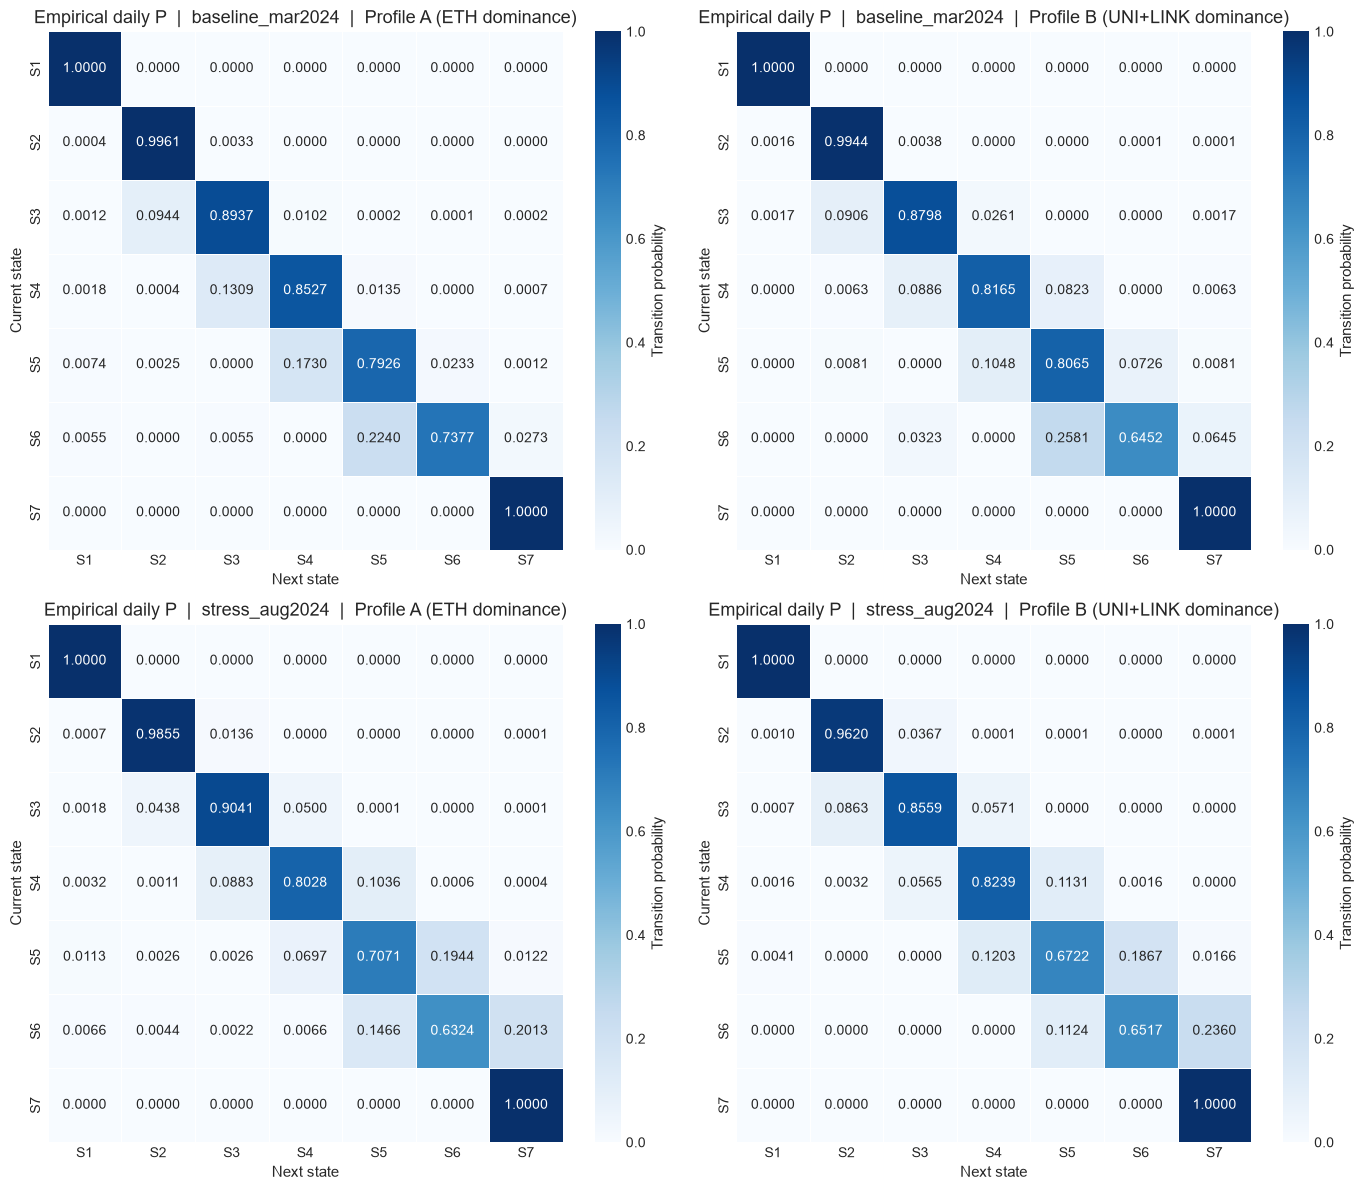

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

STATE_ORDER = ["S1", "S2", "S3", "S4", "S5", "S6", "S7"]
SCENARIO_KEYS = [
    ("baseline", "baseline_mar2024"),
    ("stress", "stress_aug2024"),
]
PROFILE_KEYS = ["A", "B"]
PROFILE_TITLES = {
    "A": "Profile A (ETH dominance)",
    "B": "Profile B (UNI+LINK dominance)",
}


def build_empirical_transition_matrices(
    subset: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return empirical count matrix N and row-stochastic matrix P.

    N is the frequency of transition_pair values. No absorbing row is
    overwritten. Rows with zero mass stay at 0 after normalization.
    """
    zeros = pd.DataFrame(0.0, index=STATE_ORDER, columns=STATE_ORDER)
    if subset.empty:
        return zeros.copy(), zeros.copy()

    counts = pd.crosstab(subset["state"], subset["next_state"])
    counts = counts.reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0).astype(float)
    row_totals = counts.sum(axis=1)
    transition_p = counts.div(row_totals.replace(0, pd.NA), axis=0).fillna(0.0)
    return counts, transition_p


empirical_N: dict[tuple[str, str], pd.DataFrame] = {}
empirical_P: dict[tuple[str, str], pd.DataFrame] = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

plot_idx = 0
for scenario_key, scenario_label in SCENARIO_KEYS:
    for profile in PROFILE_KEYS:
        subset = markov_transitions_df.loc[
            (markov_transitions_df["scenario"] == scenario_key)
            & (markov_transitions_df["profile"] == profile)
        ].copy()
        counts_n, transition_p = build_empirical_transition_matrices(subset)
        empirical_N[(scenario_label, profile)] = counts_n
        empirical_P[(scenario_label, profile)] = transition_p

        ax = axes[plot_idx]
        sns.heatmap(
            transition_p,
            ax=ax,
            annot=True,
            fmt=".4f",
            cmap="Blues",
            vmin=0.0,
            vmax=1.0,
            linewidths=0.4,
            cbar_kws={"label": "Transition probability"},
        )
        ax.set_title(
            f"Empirical daily P  |  {scenario_label}  |  {PROFILE_TITLES[profile]}"
        )
        ax.set_xlabel("Next state")
        ax.set_ylabel("Current state")

        n_s1_stay = int(counts_n.loc["S1", "S1"])
        n_s7_stay = int(counts_n.loc["S7", "S7"])
        p_s1_stay = float(transition_p.loc["S1", "S1"])
        p_s7_stay = float(transition_p.loc["S7", "S7"])
        print(
            f"{scenario_label} | {PROFILE_TITLES[profile]}: "
            f"N={len(subset):,}  "
            f"N(S1->S1)={n_s1_stay:,} P(S1->S1)={p_s1_stay:.4f}  "
            f"N(S7->S7)={n_s7_stay:,} P(S7->S7)={p_s7_stay:.4f}"
        )
        print(f"  row sums: {transition_p.sum(axis=1).round(6).tolist()}")
        plot_idx += 1

plt.tight_layout()
plt.show()